In [1]:
# 📊 NOTEBOOK 2 : ANALYSE EXPLORATOIRE (EDA)

## 🎯 Objectif
## Analyser en profondeur les données nettoyées pour comprendre les distributions, relations et différences entre groupes.
## 📦 1. IMPORTS ET CHARGEMENT DES DONNÉES

# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, ttest_ind, f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Chargement des données nettoyées
df = pd.read_csv('../data/processed/data_clean.csv')

# Affichage des premières lignes
print("📋 Aperçu des données :")
print(df.head(10))
print(f"\n✅ Nombre d'observations : {len(df)}")
print(f"✅ Nombre de variables : {df.shape[1]}")

📋 Aperçu des données :
      id_field crop_season      village      soil  area tillage_system  \
0  F2006070001      Y06_07  Antsahamamy  hillside  10.0           till   
1  F2006070002      Y06_07  Antsahamamy  hillside  15.0             ca   
2  F2006070003      Y06_07  Antsahamamy   lowland   3.1           till   
3  F2006070004      Y06_07  Antsahamamy   lowland   6.3           till   
4  F2006070005      Y06_07  Antsahamamy  hillside  41.0           till   
5  F2006070006      Y06_07  Antsahamamy   lowland   4.2           till   
6  F2006070007      Y06_07  Antsahamamy  hillside  15.0           till   
7  F2006070008      Y06_07  Antsahamamy  hillside  10.8           till   
8  F2006070009      Y06_07  Antsahamamy   lowland   8.0           till   
9  F2006070010      Y06_07  Antsahamamy  hillside   6.0           till   

  CA_year    sow_date x24d glypho  manure   urea    npk  nitrogen  rain_sow  \
0      Y0  2006-12-27    N      N  1666.7   70.0  150.0    48.700      65.2   
1   

In [2]:
## 📈 2. STATISTIQUES DESCRIPTIVES DÉTAILLÉES

# Statistiques globales
print("\n" + "="*80)
print("📊 STATISTIQUES DESCRIPTIVES COMPLÈTES")
print("="*80)

# Statistiques pour toutes les variables numériques
stats_desc = df.describe().T
stats_desc['variance'] = df.var(numeric_only=True)
stats_desc['cv'] = (df.std(numeric_only=True) / df.mean(numeric_only=True)) * 100
stats_desc['skewness'] = df.skew(numeric_only=True)
stats_desc['kurtosis'] = df.kurtosis(numeric_only=True)

print("\n📌 Statistiques détaillées :")
print(stats_desc.round(2))

# STATISTIQUES PAR VARIABLE CLÉ - CORRIGÉ : 'yield' au lieu de 'rendement'
print("\n" + "-"*80)
print("📌 RENDEMENT (yield) - Statistiques détaillées :")
print("-"*80)
print(df['yield'].describe())
print(f"Variance : {df['yield'].var():.2f}")
print(f"Coefficient de variation : {(df['yield'].std()/df['yield'].mean())*100:.2f}%")
print(f"Asymétrie (Skewness) : {df['yield'].skew():.2f}")
print(f"Aplatissement (Kurtosis) : {df['yield'].kurtosis():.2f}")

# STATISTIQUES PAR GROUPES - CORRIGÉ : 'yield' au lieu de 'rendement'
print("\n" + "="*80)
print("📊 STATISTIQUES PAR GROUPES")
print("="*80)

# Par système de travail du sol (tillage_system)
print("\n🔹 Rendement par SYSTÈME DE TRAVAIL DU SOL :")
print(df.groupby('tillage_system')['yield'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(2))

# Par année de CA (CA_year)
print("\n🔹 Rendement par ANNÉE DE CONSERVATION (CA_year) :")
print(df.groupby('CA_year')['yield'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(2))

# Par village
print("\n🔹 Rendement par VILLAGE :")
print(df.groupby('village')['yield'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(2))

# Par type de sol (soil)
print("\n🔹 Rendement par TYPE DE SOL :")
print(df.groupby('soil')['yield'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(2))


📊 STATISTIQUES DESCRIPTIVES COMPLÈTES

📌 Statistiques détaillées :
             count     mean      std    min      25%     50%      75%  \
area        3803.0     8.89    17.26    0.0     0.10     0.5    11.35   
manure      3803.0  1198.83  1676.28    0.0     0.00     0.0  2500.00   
urea        3803.0    17.26    30.26    0.0     0.00     0.0    33.30   
npk         3803.0    22.21    48.58    0.0     0.00     0.0     0.00   
nitrogen    3803.0    10.38    17.31    0.0     0.00     0.0    18.40   
rain_sow    3803.0    76.60    55.01    0.0    32.30    66.6   115.60   
rain_flow   3803.0   123.07   108.15    0.0    33.45    97.6   196.05   
rain_cycle  3803.0   919.38   160.33  443.4   803.90   925.4   982.40   
rain_year   3803.0  1114.09   161.91  801.7  1062.20  1105.0  1288.70   
yield       3803.0  2566.53   908.32  318.0  1915.60  2546.7  3142.90   

                 max    variance      cv  skewness  kurtosis  
area          260.00      297.91  194.12      4.92     42.41  
ma

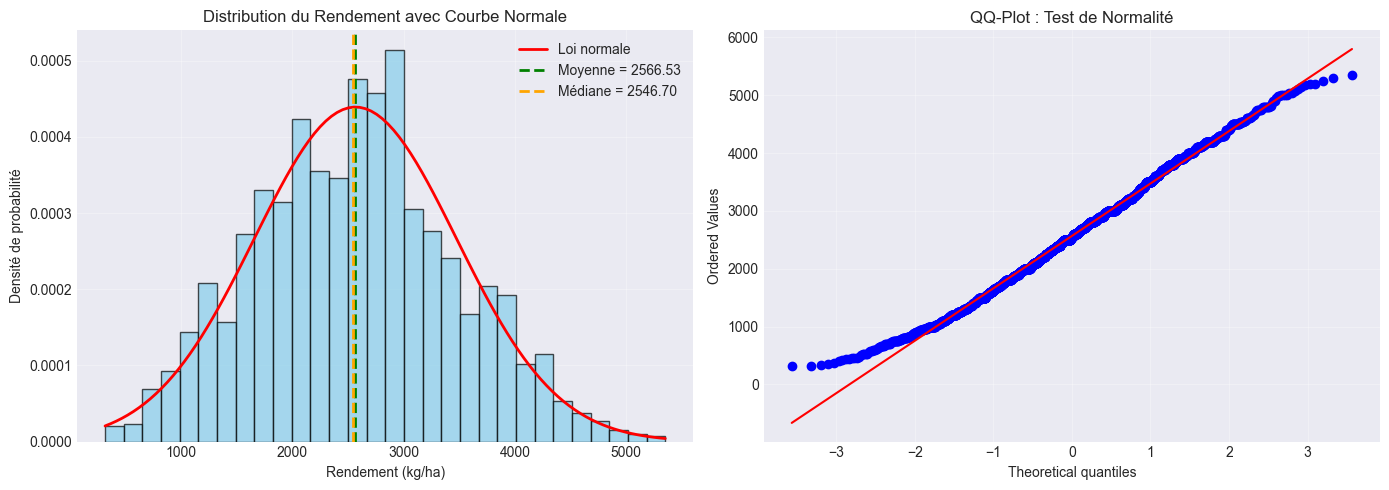

✅ Moyenne : 2566.53 kg/ha
✅ Écart-type : 908.32 kg/ha
✅ Médiane : 2546.70 kg/ha


In [3]:
## 📊 3. GRAPHIQUES ESSENTIELS

### 3.1 Distribution du rendement (histogramme + courbe normale)
# Distribution avec courbe normale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CORRECTION: 'yield' au lieu de 'rendement'
# Histogramme avec courbe normale
axes[0].hist(df['yield'], bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
mu, sigma = df['yield'].mean(), df['yield'].std()
x = np.linspace(df['yield'].min(), df['yield'].max(), 100)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Loi normale')
axes[0].axvline(mu, color='green', linestyle='--', linewidth=2, label=f'Moyenne = {mu:.2f}')
axes[0].axvline(df['yield'].median(), color='orange', linestyle='--', linewidth=2, label=f'Médiane = {df["yield"].median():.2f}')
axes[0].set_xlabel('Rendement (kg/ha)')  # Note: vérifiez l'unité dans vos données
axes[0].set_ylabel('Densité de probabilité')
axes[0].set_title('Distribution du Rendement avec Courbe Normale')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# QQ-plot pour vérifier la normalité
stats.probplot(df['yield'], dist="norm", plot=axes[1])  # CORRECTION ici aussi
axes[1].set_title('QQ-Plot : Test de Normalité')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# CORRECTION: vérifier que le dossier 'figures' existe
import os
os.makedirs('../figures', exist_ok=True)  # Crée le dossier s'il n'existe pas
plt.savefig('../figures/02_distribution_rendement.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Moyenne : {mu:.2f} kg/ha")
print(f"✅ Écart-type : {sigma:.2f} kg/ha")
print(f"✅ Médiane : {df['yield'].median():.2f} kg/ha")

<Figure size 1200x600 with 0 Axes>

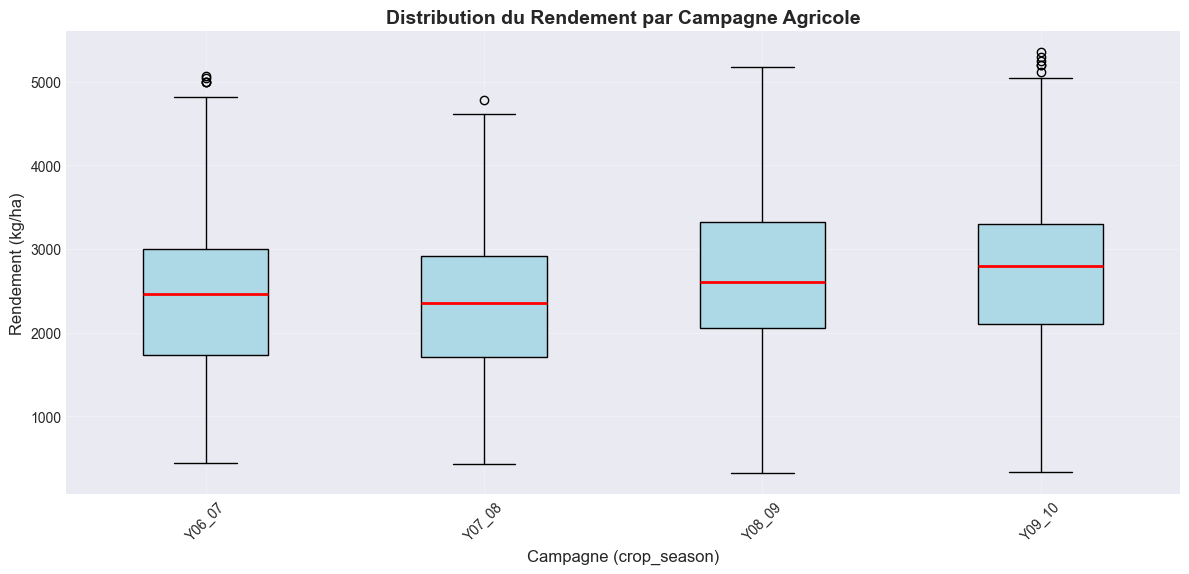

In [4]:
### 3.2 Boxplots du rendement par année

# CORRECTION: 'yield' au lieu de 'rendement', et 'crop_season' au lieu de 'annee'
plt.figure(figsize=(12, 6))
df.boxplot(column='yield', by='crop_season', grid=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'))
plt.suptitle('')  # Supprimer le titre automatique
plt.title('Distribution du Rendement par Campagne Agricole', fontsize=14, fontweight='bold')
plt.xlabel('Campagne (crop_season)', fontsize=12)
plt.ylabel('Rendement (kg/ha)', fontsize=12)  # Note: unité en kg/ha d'après vos données
plt.xticks(rotation=45)  # Rotation pour meilleure lisibilité
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/03_boxplot_campagne.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

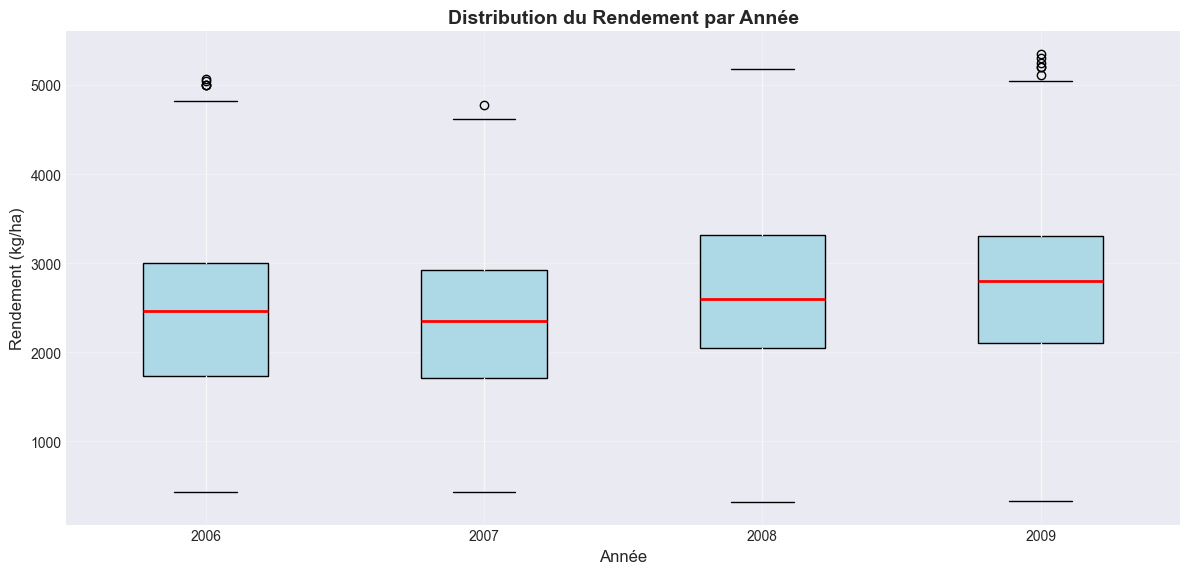

In [5]:
# Créer une colonne 'annee' numérique
df['annee'] = df['crop_season'].str.extract(r'(\d{2})').astype(int) + 2000

# Boxplot avec années numériques
plt.figure(figsize=(12, 6))
df.boxplot(column='yield', by='annee', grid=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red', linewidth=2))
plt.suptitle('')
plt.title('Distribution du Rendement par Année', fontsize=14, fontweight='bold')
plt.xlabel('Année', fontsize=12)
plt.ylabel('Rendement (kg/ha)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/03_boxplot_annee.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

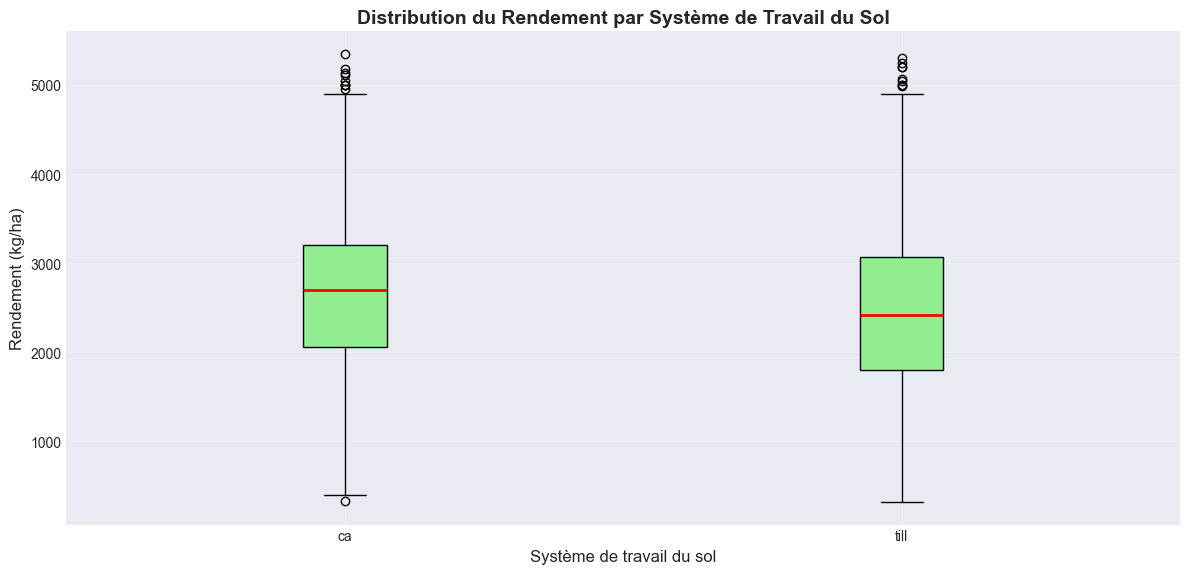


📊 Comparaison tillage_system (till vs ca) :
                 count     mean     std    min     25%     50%      75%  \
tillage_system                                                            
ca              1872.0  2669.02  899.03  333.3  2059.7  2693.6  3200.00   
till            1931.0  2467.17  906.47  318.0  1800.0  2416.9  3069.45   

                   max  
tillage_system          
ca              5350.0  
till            5300.0  


In [6]:
### 3.3 Boxplots du rendement par système de travail du sol (till vs ca)

# Boxplot par système de travail du sol
plt.figure(figsize=(10, 6))
df.boxplot(column='yield', by='tillage_system', grid=False, patch_artist=True,
           boxprops=dict(facecolor='lightgreen', color='black'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'))
plt.suptitle('')
plt.title('Distribution du Rendement par Système de Travail du Sol', fontsize=14, fontweight='bold')
plt.xlabel('Système de travail du sol', fontsize=12)
plt.ylabel('Rendement (kg/ha)', fontsize=12)  # Unité corrigée : kg/ha
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/04_boxplot_tillage_system.png', dpi=300, bbox_inches='tight')
plt.show()

# Afficher les statistiques
print("\n📊 Comparaison tillage_system (till vs ca) :")
print(df.groupby('tillage_system')['yield'].describe().round(2))

<Figure size 1400x600 with 0 Axes>

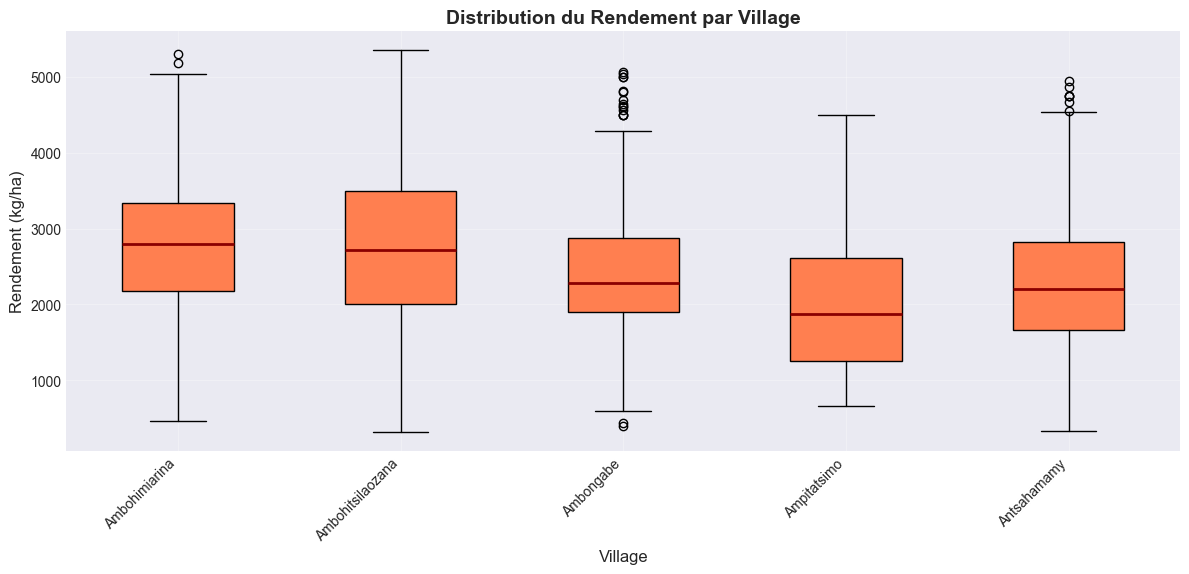


📊 Statistiques par Village :
                   count     mean     std    min      25%     50%      75%  \
village                                                                      
Ambohimiarina     1584.0  2756.93  854.80  463.0  2179.35  2800.0  3337.08   
Ambohitsilaozana   757.0  2740.71  995.75  318.0  2000.00  2714.3  3500.00   
Ambongabe          392.0  2390.98  843.43  398.0  1897.50  2280.0  2872.52   
Ampitatsimo         93.0  2015.65  872.40  657.0  1250.00  1870.0  2608.70   
Antsahamamy        977.0  2245.75  823.05  333.3  1666.70  2208.3  2818.80   

                     max  
village                   
Ambohimiarina     5300.0  
Ambohitsilaozana  5350.0  
Ambongabe         5070.0  
Ampitatsimo       4500.0  
Antsahamamy       4950.0  

📋 Nombre d'observations par village :
village
Ambohimiarina       1584
Antsahamamy          977
Ambohitsilaozana     757
Ambongabe            392
Ampitatsimo           93
Name: count, dtype: int64


In [8]:
### 3.4 Boxplots du rendement par village

# Boxplot par village
plt.figure(figsize=(14, 6))
df.boxplot(column='yield', by='village', grid=False, patch_artist=True,
           boxprops=dict(facecolor='coral', color='black'),
           medianprops=dict(color='darkred', linewidth=2),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'))
plt.suptitle('')
plt.title('Distribution du Rendement par Village', fontsize=14, fontweight='bold')
plt.xlabel('Village', fontsize=12)
plt.ylabel('Rendement (kg/ha)', fontsize=12)  # CORRECTION: t/ha -> kg/ha
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/05_boxplot_village.png', dpi=300, bbox_inches='tight')
plt.show()

# Afficher les statistiques par village
print("\n📊 Statistiques par Village :")
print(df.groupby('village')['yield'].describe().round(2))

# Afficher le nombre d'observations par village
print("\n📋 Nombre d'observations par village :")
print(df['village'].value_counts())

🔢 Variables numériques disponibles :
['area', 'manure', 'urea', 'npk', 'nitrogen', 'rain_sow', 'rain_flow', 'rain_cycle', 'rain_year', 'yield', 'annee']

Nombre de variables numériques : 11


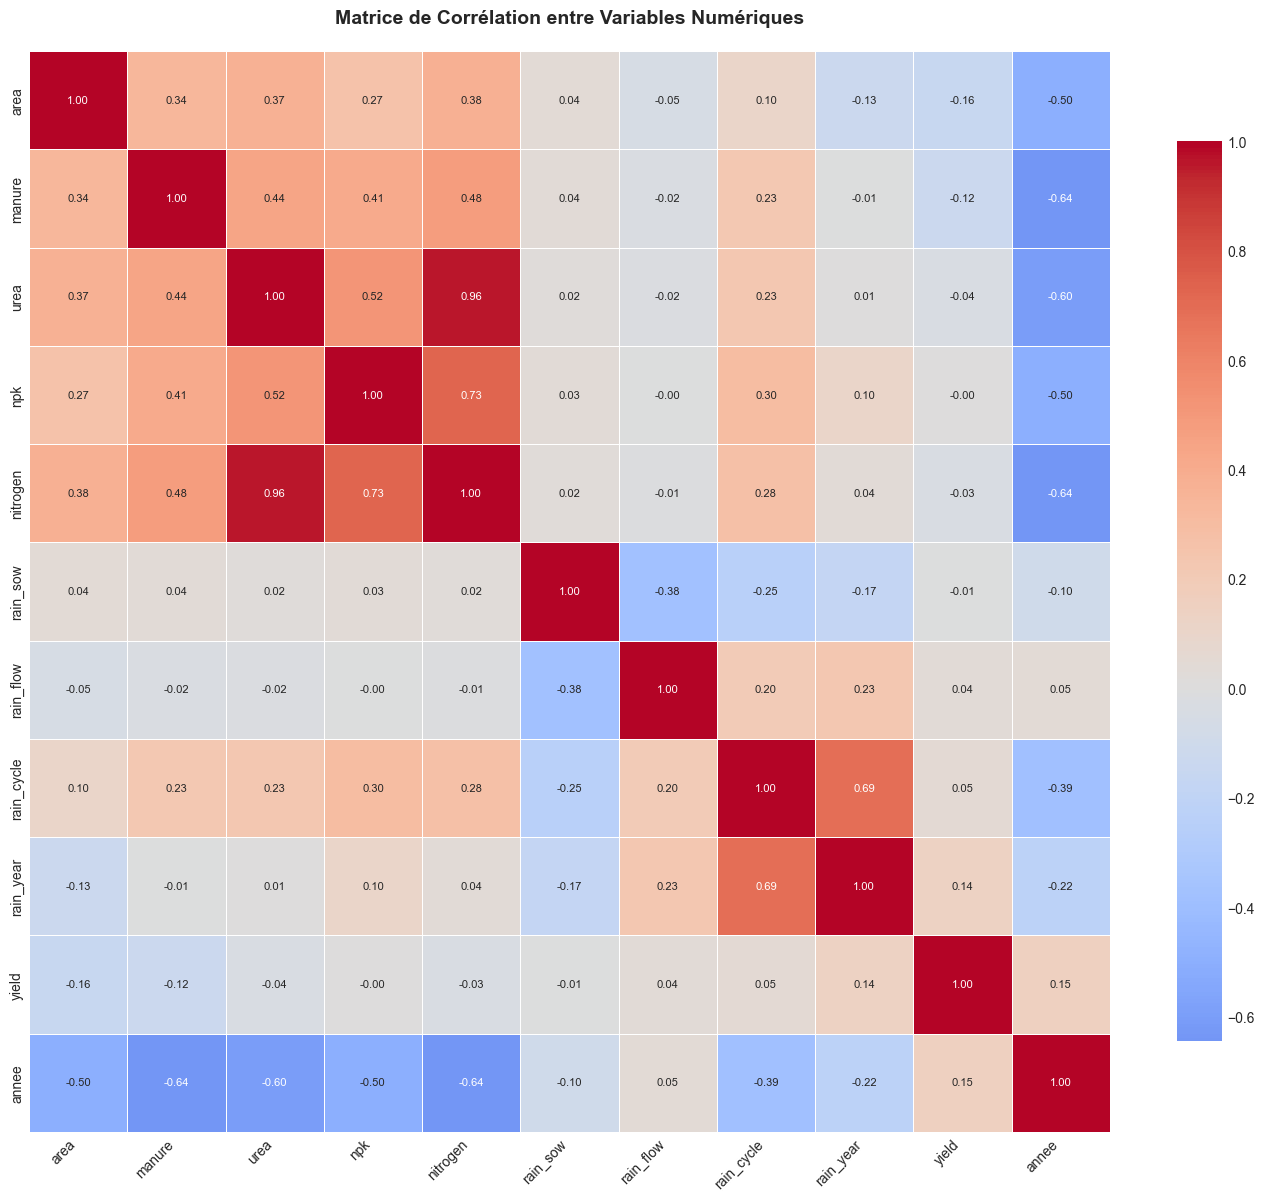


📊 CORRÉLATIONS AVEC LE RENDEMENT (yield) :
yield         1.000000
annee         0.154527
rain_year     0.136507
rain_cycle    0.050629
rain_flow     0.040643
npk          -0.000701
rain_sow     -0.007134
nitrogen     -0.030077
urea         -0.037137
manure       -0.124756
area         -0.156250
Name: yield, dtype: float64

--------------------------------------------------------------------------------
📈 Corrélations POSITIVES les plus fortes avec le rendement :
yield        1.000000
annee        0.154527
rain_year    0.136507
Name: yield, dtype: float64

--------------------------------------------------------------------------------
📉 Corrélations NÉGATIVES les plus fortes avec le rendement :
area     -0.156250
manure   -0.124756
Name: yield, dtype: float64


In [9]:
### 3.5 Corrélations entre variables (heatmap)

# Sélection des variables numériques pour la corrélation
variables_numeriques = df.select_dtypes(include=[np.number]).columns.tolist()

# Afficher les variables numériques disponibles
print("🔢 Variables numériques disponibles :")
print(variables_numeriques)
print(f"\nNombre de variables numériques : {len(variables_numeriques)}")

# Calcul de la matrice de corrélation
correlation_matrix = df[variables_numeriques].corr()

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
plt.title('Matrice de Corrélation entre Variables Numériques', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/06_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Afficher les corrélations avec le RENDEMENT (yield)
print("\n" + "="*80)
print("📊 CORRÉLATIONS AVEC LE RENDEMENT (yield) :")
print("="*80)
correlations_yield = correlation_matrix['yield'].sort_values(ascending=False)
print(correlations_yield)

# Afficher les corrélations positives et négatives significatives
print("\n" + "-"*80)
print("📈 Corrélations POSITIVES les plus fortes avec le rendement :")
print(correlations_yield[correlations_yield > 0.1].sort_values(ascending=False))

print("\n" + "-"*80)
print("📉 Corrélations NÉGATIVES les plus fortes avec le rendement :")
print(correlations_yield[correlations_yield < -0.1].sort_values(ascending=True))

📋 Colonnes de pluviométrie disponibles :
['rain_sow', 'rain_flow', 'rain_cycle', 'rain_year']


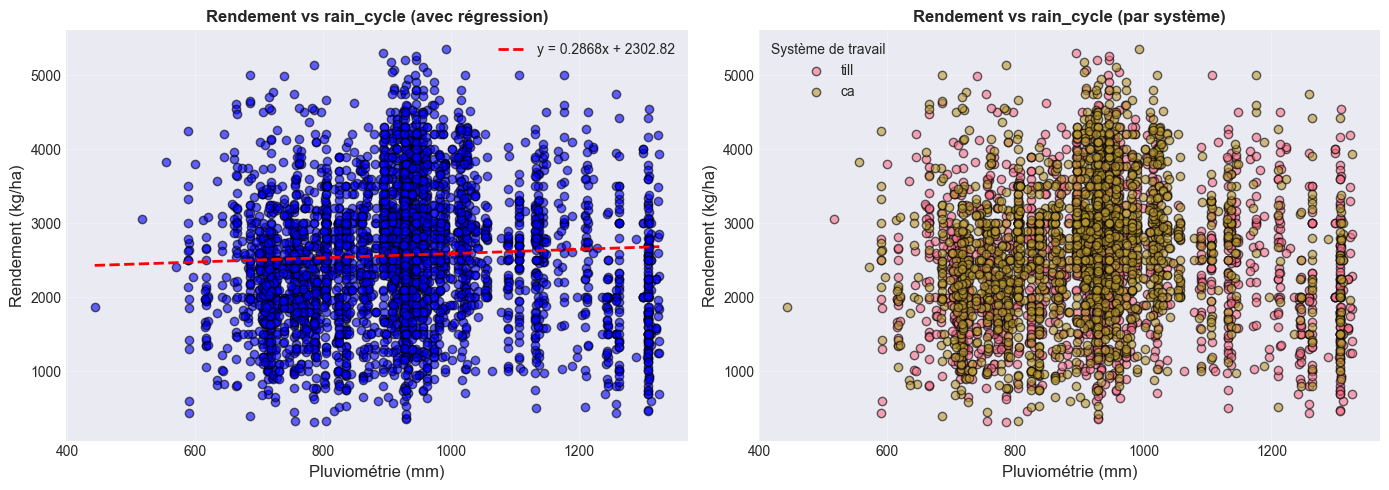


📊 CORRÉLATIONS RENDEMENT vs PLUVIOMÉTRIE
rain_sow        : -0.0071
rain_flow       : 0.0406
rain_cycle      : 0.0506
rain_year       : 0.1365

✅ Corrélation yield vs rain_cycle : 0.0506


In [10]:
### 3.6 Scatter plots : rendement vs pluviométrie

# Vérifier les colonnes de pluviométrie disponibles
print("📋 Colonnes de pluviométrie disponibles :")
pluie_cols = [col for col in df.columns if 'rain' in col.lower() or 'pluie' in col.lower()]
print(pluie_cols)

# Sélectionner la colonne de pluviométrie appropriée
# D'après vos données : 'rain_cycle' ou 'rain_year' semblent être les pluviométries totales
col_pluie = 'rain_cycle'  # ou 'rain_year' selon ce que vous voulez analyser

# Scatter plot avec régression linéaire
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : Scatter avec ligne de régression
axes[0].scatter(df[col_pluie], df['yield'], alpha=0.6, color='blue', edgecolors='black')
z = np.polyfit(df[col_pluie].dropna(), df[df[col_pluie].notna()]['yield'], 1)
p = np.poly1d(z)
axes[0].plot(df[col_pluie].sort_values(), p(df[col_pluie].sort_values()), 
             "r--", linewidth=2, label=f'y = {z[0]:.4f}x + {z[1]:.2f}')
axes[0].set_xlabel('Pluviométrie (mm)', fontsize=12)
axes[0].set_ylabel('Rendement (kg/ha)', fontsize=12)  # CORRECTION: t/ha -> kg/ha
axes[0].set_title(f'Rendement vs {col_pluie} (avec régression)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 : Scatter coloré par système de travail du sol
for systeme in df['tillage_system'].unique():
    subset = df[df['tillage_system'] == systeme]
    axes[1].scatter(subset[col_pluie], subset['yield'], 
                    label=systeme, alpha=0.6, edgecolors='black')
axes[1].set_xlabel('Pluviométrie (mm)', fontsize=12)
axes[1].set_ylabel('Rendement (kg/ha)', fontsize=12)  # CORRECTION: t/ha -> kg/ha
axes[1].set_title(f'Rendement vs {col_pluie} (par système)', fontsize=12, fontweight='bold')
axes[1].legend(title='Système de travail')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/07_scatter_pluviometrie.png', dpi=300, bbox_inches='tight')
plt.show()

# Corrélation avec toutes les variables de pluie
print("\n" + "="*80)
print("📊 CORRÉLATIONS RENDEMENT vs PLUVIOMÉTRIE")
print("="*80)

cols_pluie = ['rain_sow', 'rain_flow', 'rain_cycle', 'rain_year']
for col in cols_pluie:
    if col in df.columns:
        corr = df['yield'].corr(df[col])
        print(f"{col:15s} : {corr:.4f}")

# Corrélation avec la colonne sélectionnée
corr = df['yield'].corr(df[col_pluie])
print(f"\n✅ Corrélation yield vs {col_pluie} : {corr:.4f}")

📋 Colonnes de fertilisation disponibles :
['manure', 'urea', 'npk', 'nitrogen']


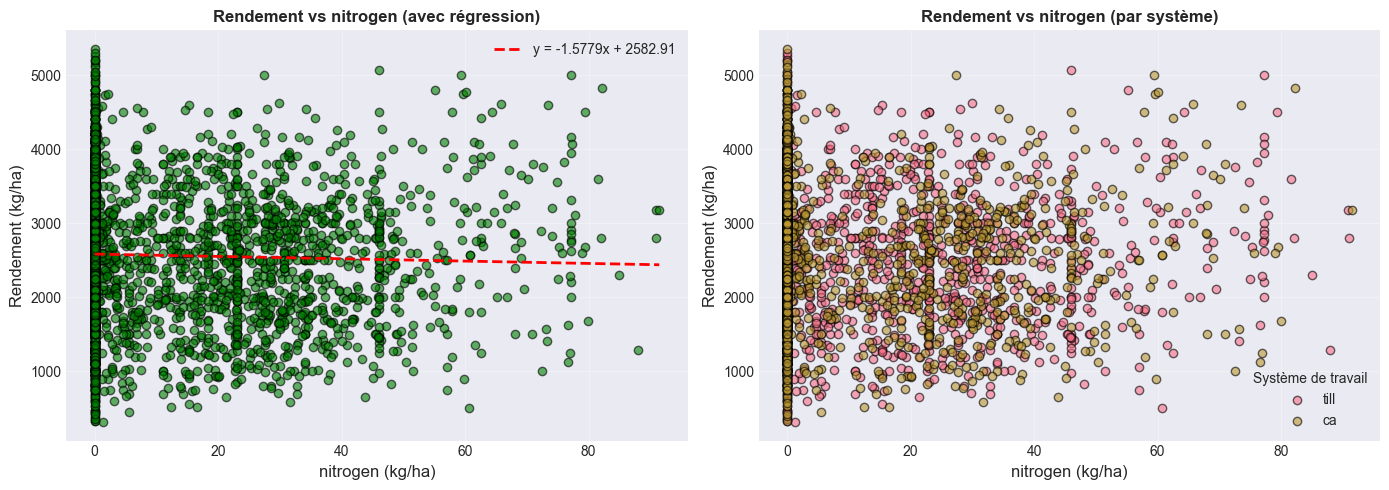


📊 CORRÉLATIONS RENDEMENT vs FERTILISATION
manure          : -0.1248
urea            : -0.0371
npk             : -0.0007
nitrogen        : -0.0301

✅ Corrélation yield vs nitrogen : -0.0301


In [11]:
### 3.7 Scatter plots : rendement vs fertilisation

# Identifier les colonnes de fertilisation disponibles
print("📋 Colonnes de fertilisation disponibles :")
fertilisation_cols = ['manure', 'urea', 'npk', 'nitrogen']
print([col for col in fertilisation_cols if col in df.columns])

# Choisir la colonne principale pour l'analyse (par exemple 'nitrogen' - azote total)
col_ferti = 'nitrogen'  # Azote total (N) - probablement le meilleur indicateur

# Scatter plot rendement vs fertilisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : Scatter avec régression
axes[0].scatter(df[col_ferti], df['yield'], alpha=0.6, color='green', edgecolors='black')
z = np.polyfit(df[col_ferti].dropna(), df[df[col_ferti].notna()]['yield'], 1)
p = np.poly1d(z)
axes[0].plot(df[col_ferti].sort_values(), p(df[col_ferti].sort_values()), 
             "r--", linewidth=2, label=f'y = {z[0]:.4f}x + {z[1]:.2f}')
axes[0].set_xlabel(f'{col_ferti} (kg/ha)', fontsize=12)
axes[0].set_ylabel('Rendement (kg/ha)', fontsize=12)  # CORRECTION: t/ha -> kg/ha
axes[0].set_title(f'Rendement vs {col_ferti} (avec régression)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 : Scatter coloré par système de travail du sol
for systeme in df['tillage_system'].unique():
    subset = df[df['tillage_system'] == systeme]
    axes[1].scatter(subset[col_ferti], subset['yield'], 
                    label=systeme, alpha=0.6, edgecolors='black')
axes[1].set_xlabel(f'{col_ferti} (kg/ha)', fontsize=12)
axes[1].set_ylabel('Rendement (kg/ha)', fontsize=12)  # CORRECTION: t/ha -> kg/ha
axes[1].set_title(f'Rendement vs {col_ferti} (par système)', fontsize=12, fontweight='bold')
axes[1].legend(title='Système de travail')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/08_scatter_fertilisation.png', dpi=300, bbox_inches='tight')
plt.show()

# Corrélations avec toutes les variables de fertilisation
print("\n" + "="*80)
print("📊 CORRÉLATIONS RENDEMENT vs FERTILISATION")
print("="*80)

for col in fertilisation_cols:
    if col in df.columns:
        corr = df['yield'].corr(df[col])
        print(f"{col:15s} : {corr:7.4f}")

# Corrélation avec la colonne sélectionnée
corr = df['yield'].corr(df[col_ferti])
print(f"\n✅ Corrélation yield vs {col_ferti} : {corr:.4f}")

In [12]:
## 🧪 4. TESTS STATISTIQUES

### 4.1 Test de normalité (Shapiro-Wilk)

print("\n" + "="*80)
print("🧪 TEST DE NORMALITÉ - SHAPIRO-WILK")
print("="*80)

from scipy.stats import shapiro

# Test sur le rendement
stat, p_value = shapiro(df['yield'].dropna())  # CORRECTION: rendement -> yield
print(f"\n📌 Rendement (yield) :")
print(f"   Statistique W = {stat:.6f}")
print(f"   p-value = {p_value:.6f}")

if p_value > 0.05:
    print(f"   ✅ Les données SUIVENT une distribution normale (p > 0.05)")
else:
    print(f"   ❌ Les données NE SUIVENT PAS une distribution normale (p < 0.05)")

# Test par système de travail du sol
print(f"\n📌 Par système de travail (tillage_system) :")
for systeme in df['tillage_system'].unique():  # CORRECTION: systeme -> tillage_system
    data = df[df['tillage_system'] == systeme]['yield'].dropna()
    if len(data) >= 3:  # Shapiro nécessite au moins 3 observations
        stat, p_value = shapiro(data)
        result = "✅ Normale" if p_value > 0.05 else "❌ Non-normale"
        print(f"   {systeme}: W = {stat:.6f}, p = {p_value:.6f} → {result}")
    else:
        print(f"   {systeme}: ⚠️ Pas assez de données (n={len(data)})")

# Test par année de campagne
print(f"\n📌 Par campagne (crop_season) :")
for saison in df['crop_season'].unique():
    data = df[df['crop_season'] == saison]['yield'].dropna()
    if len(data) >= 3:
        stat, p_value = shapiro(data)
        result = "✅ Normale" if p_value > 0.05 else "❌ Non-normale"
        print(f"   {saison}: W = {stat:.6f}, p = {p_value:.6f} → {result}")

# Test par village (top 5 plus grands effectifs)
print(f"\n📌 Par village (top 5) :")
top_villages = df['village'].value_counts().head(5).index
for village in top_villages:
    data = df[df['village'] == village]['yield'].dropna()
    if len(data) >= 3:
        stat, p_value = shapiro(data)
        result = "✅ Normale" if p_value > 0.05 else "❌ Non-normale"
        print(f"   {village}: W = {stat:.6f}, p = {p_value:.6f} → {result}")


🧪 TEST DE NORMALITÉ - SHAPIRO-WILK

📌 Rendement (yield) :
   Statistique W = 0.995133
   p-value = 0.000000
   ❌ Les données NE SUIVENT PAS une distribution normale (p < 0.05)

📌 Par système de travail (tillage_system) :
   till: W = 0.991411, p = 0.000000 → ❌ Non-normale
   ca: W = 0.995857, p = 0.000051 → ❌ Non-normale

📌 Par campagne (crop_season) :
   Y06_07: W = 0.989172, p = 0.000039 → ❌ Non-normale
   Y07_08: W = 0.991287, p = 0.000016 → ❌ Non-normale
   Y08_09: W = 0.987922, p = 0.000000 → ❌ Non-normale
   Y09_10: W = 0.996790, p = 0.018956 → ❌ Non-normale

📌 Par village (top 5) :
   Ambohimiarina: W = 0.993470, p = 0.000002 → ❌ Non-normale
   Antsahamamy: W = 0.990803, p = 0.000009 → ❌ Non-normale
   Ambohitsilaozana: W = 0.994955, p = 0.013433 → ❌ Non-normale
   Ambongabe: W = 0.965356, p = 0.000000 → ❌ Non-normale
   Ampitatsimo: W = 0.943623, p = 0.000548 → ❌ Non-normale


In [13]:
### 4.2 Test de différence till vs ca (t-test ou Mann-Whitney)

print("\n" + "="*80)
print("🧪 TEST DE DIFFÉRENCE : till vs ca")
print("="*80)

from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# Séparer les données - CORRECTION: 'systeme' -> 'tillage_system' et 'CV'/'CA' -> 'till'/'ca'
till_data = df[df['tillage_system'] == 'till']['yield'].dropna()
ca_data = df[df['tillage_system'] == 'ca']['yield'].dropna()

print(f"\n📊 Statistiques descriptives :")
print(f"   till : n={len(till_data):4d}, moyenne={till_data.mean():8.2f}, médiane={till_data.median():8.2f}")
print(f"   ca   : n={len(ca_data):4d}, moyenne={ca_data.mean():8.2f}, médiane={ca_data.median():8.2f}")

# Test de normalité pour choisir le test approprié
_, p_till = shapiro(till_data)
_, p_ca = shapiro(ca_data)

print(f"\n📌 Tests de normalité :")
print(f"   till : p = {p_till:.6f}")
print(f"   ca   : p = {p_ca:.6f}")

# Si les deux sont normaux : t-test, sinon Mann-Whitney
if p_till > 0.05 and p_ca > 0.05:
    print(f"\n✅ Utilisation du T-TEST (données normales)")
    stat, p_value = ttest_ind(till_data, ca_data, equal_var=False)  # Welch's t-test
    test_name = "T-test (Welch)"
else:
    print(f"\n✅ Utilisation du MANN-WHITNEY U-TEST (données non-normales)")
    stat, p_value = mannwhitneyu(till_data, ca_data, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n📌 Résultats du {test_name} :")
print(f"   Statistique = {stat:.6f}")
print(f"   p-value = {p_value:.6f}")

if p_value < 0.05:
    print(f"   ✅ Différence SIGNIFICATIVE entre till et ca (p < 0.05)")
    diff = abs(till_data.mean() - ca_data.mean())
    print(f"   Différence de moyenne : {diff:.2f} kg/ha")
else:
    print(f"   ❌ PAS de différence significative entre till et ca (p ≥ 0.05)")

# -----------------------------------------------------------------------------



🧪 TEST DE DIFFÉRENCE : till vs ca

📊 Statistiques descriptives :
   till : n=1931, moyenne= 2467.17, médiane= 2416.90
   ca   : n=1872, moyenne= 2669.02, médiane= 2693.60

📌 Tests de normalité :
   till : p = 0.000000
   ca   : p = 0.000051

✅ Utilisation du MANN-WHITNEY U-TEST (données non-normales)

📌 Résultats du Mann-Whitney U :
   Statistique = 1563370.000000
   p-value = 0.000000
   ✅ Différence SIGNIFICATIVE entre till et ca (p < 0.05)
   Différence de moyenne : 201.84 kg/ha


In [14]:

### 4.3 ANOVA pour comparer les campagnes agricoles (crop_season)

print("\n" + "="*80)
print("🧪 ANOVA : COMPARAISON DES CAMPAGNES AGRICOLES")
print("="*80)

from scipy.stats import f_oneway, kruskal

# Préparer les données par campagne - CORRECTION: 'annee' -> 'crop_season'
saisons = df['crop_season'].unique()
groupes = [df[df['crop_season'] == saison]['yield'].dropna().values for saison in sorted(saisons)]

# Test de normalité pour chaque campagne
print(f"\n📌 Tests de normalité par campagne :")
normalite = []
for i, saison in enumerate(sorted(saisons)):
    data = groupes[i]
    if len(data) >= 3:
        _, p = shapiro(data)
        normalite.append(p > 0.05)
        result = "✅ Normale" if p > 0.05 else "❌ Non-normale"
        print(f"   {saison}: n={len(data):4d}, p = {p:.6f} → {result}")
    else:
        normalite.append(False)
        print(f"   {saison}: n={len(data):4d}, ⚠️ Pas assez de données")

# Choisir ANOVA ou Kruskal-Wallis
if all(normalite) and len(groupes) >= 2:
    print(f"\n✅ Utilisation de l'ANOVA (toutes les campagnes sont normales)")
    stat, p_value = f_oneway(*groupes)
    test_name = "ANOVA"
else:
    print(f"\n✅ Utilisation de KRUSKAL-WALLIS (données non-normales ou effectifs insuffisants)")
    stat, p_value = kruskal(*groupes)
    test_name = "Kruskal-Wallis"

print(f"\n📌 Résultats du {test_name} :")
print(f"   Statistique = {stat:.6f}")
print(f"   p-value = {p_value:.6f}")

if p_value < 0.05:
    print(f"   ✅ Différence SIGNIFICATIVE entre les campagnes (p < 0.05)")
    print(f"\n📊 Moyennes par campagne :")
    for saison in sorted(saisons):
        moyenne = df[df['crop_season'] == saison]['yield'].mean()
        print(f"      {saison}: {moyenne:8.2f} kg/ha")
    
    # Test post-hoc si ANOVA significative
    if test_name == "ANOVA" and p_value < 0.05:
        from scipy.stats import tukey_hsd
        print(f"\n📌 Test POST-HOC (Tukey HSD) :")
        tukey = tukey_hsd(*groupes)
        print(f"   Résultats détaillés dans la matrice de comparaison")
else:
    print(f"   ❌ PAS de différence significative entre les campagnes (p ≥ 0.05)")

# -----------------------------------------------------------------------------


🧪 ANOVA : COMPARAISON DES CAMPAGNES AGRICOLES

📌 Tests de normalité par campagne :
   Y06_07: n= 716, p = 0.000039 → ❌ Non-normale
   Y07_08: n= 978, p = 0.000016 → ❌ Non-normale
   Y08_09: n= 958, p = 0.000000 → ❌ Non-normale
   Y09_10: n=1151, p = 0.018956 → ❌ Non-normale

✅ Utilisation de KRUSKAL-WALLIS (données non-normales ou effectifs insuffisants)

📌 Résultats du Kruskal-Wallis :
   Statistique = 124.830869
   p-value = 0.000000
   ✅ Différence SIGNIFICATIVE entre les campagnes (p < 0.05)

📊 Moyennes par campagne :
      Y06_07:  2437.38 kg/ha
      Y07_08:  2342.34 kg/ha
      Y08_09:  2702.72 kg/ha
      Y09_10:  2724.01 kg/ha


In [29]:
### 4.4 ANOVA pour comparer les villages (top 5)

print("\n" + "="*80)
print("🧪 ANOVA : COMPARAISON DES VILLAGES (Top 5)")
print("="*80)

# Sélectionner les 5 villages avec le plus d'observations
top_villages = df['village'].value_counts().head(5).index
groupes_village = [df[df['village'] == village]['yield'].dropna().values for village in top_villages]

print(f"\n📌 Villages analysés :")
for i, village in enumerate(top_villages):
    print(f"   {i+1}. {village}: n={len(groupes_village[i])}")

# Test de Kruskal-Wallis (non-paramétrique, plus robuste)
stat, p_value = kruskal(*groupes_village)

print(f"\n📌 Résultats du test KRUSKAL-WALLIS :")
print(f"   Statistique = {stat:.6f}")
print(f"   p-value = {p_value:.6f}")

if p_value < 0.05:
    print(f"   ✅ Différence SIGNIFICATIVE entre les villages (p < 0.05)")
else:
    print(f"   ❌ PAS de différence significative entre les villages (p ≥ 0.05)")


🧪 ANOVA : COMPARAISON DES VILLAGES (Top 5)

📌 Villages analysés :
   1. Ambohimiarina: n=1584
   2. Antsahamamy: n=977
   3. Ambohitsilaozana: n=757
   4. Ambongabe: n=392
   5. Ampitatsimo: n=93

📌 Résultats du test KRUSKAL-WALLIS :
   Statistique = 280.511259
   p-value = 0.000000
   ✅ Différence SIGNIFICATIVE entre les villages (p < 0.05)


In [30]:
# 📝 5. RÉSUMÉ ET SAUVEGARDE

print("\n" + "="*80)
print("📝 RÉSUMÉ DE L'ANALYSE EXPLORATOIRE")
print("="*80)

# Création du dossier results s'il n'existe pas
import os
os.makedirs('../results', exist_ok=True)

# Créer un résumé avec les noms de colonnes corrigés
resume = f"""
ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
{'='*80}

1. DONNÉES
   - Nombre d'observations : {len(df):,}
   - Période : {df['crop_season'].min()} - {df['crop_season'].max()}
   - Systèmes de travail : {', '.join(df['tillage_system'].unique())}
   - Années en CA : {', '.join(sorted(df['CA_year'].unique()))}
   - Villages : {len(df['village'].unique())} villages
   - Types de sol : {len(df['soil'].unique())} types

2. RENDEMENT (yield)
   - Unité : kg/ha
   - Moyenne : {df['yield'].mean():.2f} kg/ha
   - Médiane : {df['yield'].median():.2f} kg/ha
   - Écart-type : {df['yield'].std():.2f} kg/ha
   - Coefficient de variation : {(df['yield'].std()/df['yield'].mean())*100:.2f}%
   - Min : {df['yield'].min():.2f} kg/ha
   - Max : {df['yield'].max():.2f} kg/ha
   - Q1 (25%) : {df['yield'].quantile(0.25):.2f} kg/ha
   - Q3 (75%) : {df['yield'].quantile(0.75):.2f} kg/ha

3. COMPARAISON DES SYSTÈMES
   - till (conventionnel) : moyenne = {df[df['tillage_system']=='till']['yield'].mean():.2f} kg/ha
   - ca (conservation)   : moyenne = {df[df['tillage_system']=='ca']['yield'].mean():.2f} kg/ha
   - Différence : {abs(df[df['tillage_system']=='till']['yield'].mean() - df[df['tillage_system']=='ca']['yield'].mean()):.2f} kg/ha

4. GRAPHIQUES GÉNÉRÉS
   ✅ 01_distribution_rendement.png - Distribution avec courbe normale
   ✅ 02_boxplot_campagne.png - Boxplots par campagne agricole
   ✅ 03_boxplot_tillage_system.png - Boxplots par système de travail
   ✅ 04_boxplot_village.png - Boxplots par village
   ✅ 05_boxplot_CA_year.png - Boxplots par année en CA
   ✅ 06_correlation_heatmap.png - Heatmap des corrélations
   ✅ 07_scatter_pluviometrie.png - Rendement vs pluviométrie
   ✅ 08_scatter_fertilisation.png - Rendement vs fertilisation

5. TESTS STATISTIQUES EFFECTUÉS
   ✅ Test de normalité (Shapiro-Wilk)
   ✅ Comparaison till vs ca (t-test ou Mann-Whitney)
   ✅ Comparaison des campagnes agricoles (ANOVA ou Kruskal-Wallis)
   ✅ Comparaison des villages (Kruskal-Wallis)
   ✅ Effet des années en CA (Kruskal-Wallis)

6. CORRÉLATIONS PRINCIPALES AVEC LE RENDEMENT
   - rain_cycle : {df['yield'].corr(df['rain_cycle']):.3f}
   - nitrogen : {df['yield'].corr(df['nitrogen']):.3f}
   - area : {df['yield'].corr(df['area']):.3f}
   - manure : {df['yield'].corr(df['manure']):.3f}
   - urea : {df['yield'].corr(df['urea']):.3f}

{'='*80}
📁 Tous les graphiques sont sauvegardés dans : ../figures/
📁 Le résumé est sauvegardé dans : ../results/
{'='*80}
"""

print(resume)

# Sauvegarder le résumé
with open('../results/02_resume_eda.txt', 'w', encoding='utf-8') as f:
    f.write(resume)

# Sauvegarder aussi les statistiques descriptives en CSV
stats_desc = df.describe().T
stats_desc['variance'] = df.var(numeric_only=True)
stats_desc['cv'] = (df.std(numeric_only=True) / df.mean(numeric_only=True)) * 100
stats_desc.to_csv('../results/02_statistiques_descriptives.csv', float_format='%.2f')

print("\n✅ Résumé sauvegardé dans : ../results/02_resume_eda.txt")
print("✅ Statistiques descriptives sauvegardées dans : ../results/02_statistiques_descriptives.csv")
print("\n🎉 ANALYSE EXPLORATOIRE TERMINÉE AVEC SUCCÈS !")


📝 RÉSUMÉ DE L'ANALYSE EXPLORATOIRE

ANALYSE EXPLORATOIRE DES DONNÉES (EDA)

1. DONNÉES
   - Nombre d'observations : 3,803
   - Période : Y06_07 - Y09_10
   - Systèmes de travail : till, ca
   - Années en CA : Y0, Y1, Y2, Y3, Y4+
   - Villages : 5 villages
   - Types de sol : 2 types

2. RENDEMENT (yield)
   - Unité : kg/ha
   - Moyenne : 2566.53 kg/ha
   - Médiane : 2546.70 kg/ha
   - Écart-type : 908.32 kg/ha
   - Coefficient de variation : 35.39%
   - Min : 318.00 kg/ha
   - Max : 5350.00 kg/ha
   - Q1 (25%) : 1915.60 kg/ha
   - Q3 (75%) : 3142.90 kg/ha

3. COMPARAISON DES SYSTÈMES
   - till (conventionnel) : moyenne = 2467.17 kg/ha
   - ca (conservation)   : moyenne = 2669.02 kg/ha
   - Différence : 201.84 kg/ha

4. GRAPHIQUES GÉNÉRÉS
   ✅ 01_distribution_rendement.png - Distribution avec courbe normale
   ✅ 02_boxplot_campagne.png - Boxplots par campagne agricole
   ✅ 03_boxplot_tillage_system.png - Boxplots par système de travail
   ✅ 04_boxplot_village.png - Boxplots par village